In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
copy_number_inference = lazy_import("copy_number_inference",os.path.join(utils_dir, "copy_number_inference.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors, pseudo_color
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from thresholding_functions import threshold_otsu, threshold_triangle
from copy_number_inference import plot_CNV_matrix
from gene_signatures_utils import toupper, attach_selected_signatures


Import data

In [ ]:
adata = sc.read_h5ad("../data/Reyes_KPLOH_SUBSET_all__integrated.h5ad")

Make basic plot with labeled cell states

In [ ]:
condition_simple = adata.obs['condition'].to_numpy()
condition_simple[condition_simple == 'K4microtumorSP'] = 'K4pretumorSP'
condition_simple[condition_simple == 'K5ctrl'] = 'K5tumorSP'
condition_simple[condition_simple == 'K6ctrl'] = 'K5tumorSP'
adata.obs['condition_simple'] = condition_simple.copy()

In [ ]:
adata.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata.obs['replicate_id']]
adata.obs['sample_id'] = [re.sub('.*Spontaneous_', '', x) for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [re.sub('\.\d$', '', x) for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [x.capitalize() for x in adata.obs['sample_id']]
adata.obs['sample_id'] = [re.sub('_', ' ', x) for x in adata.obs['sample_id']]
sample_id_simple = adata.obs['sample_id'].to_numpy()
sample_id_simple = [re.sub('microtumor', 'pretumor', x) for x in sample_id_simple]
sample_id_simple = [re.sub('Met', 'Tumor', x) for x in sample_id_simple] # Used only for plotting
adata.obs['sample_id_simple'] = sample_id_simple.copy()

Highlight individual samples in force-directed layout for supplementary material

In [ ]:
sample_colors = {
    'Pre-tumor p53 proficient 0':'#D6C99D',
    'Pre-tumor p53 proficient 1':'#F3C5DC',
    'Pre-tumor p53 proficient 2':'#C4DF99',
    'Pre-tumor p53 proficient 3':'#F7B494',
    'Pre-tumor p53 proficient 4':'#A3CFE4',
    'Pre-tumor p53 proficient 5':'#FDC577',
    'Pre-tumor p53 deficient 1':'#DA4699',
    'Pre-tumor p53 deficient 2':'#5CB647',
    'Pre-tumor p53 deficient 4':'#0085BE',
    'Pre-tumor p53 deficient 5':'#EB7723',
    'Tumor p53 deficient 1':'#48A9BF',
    'Tumor p53 deficient 2':'#F0D335',
    'Tumor p53 deficient 3':'#EF4023',
    'Tumor p53 deficient 4':'#008973',
    'Tumor p53 deficient 5':'#46375C',
    'Tumor p53 deficient 6':'#EB9922',
    'Tumor p53 proficient 1':'#48A9BF',
    'Tumor p53 proficient 2':'#F0D335',
    'Tumor p53 proficient 3':'#EF4023',
}

sample_colors = {
    'Pre-tumor p53 proficient 0':'#EB7723',
    'Pre-tumor p53 proficient 1':'#DA4699',
    'Pre-tumor p53 proficient 2':'#5CB647',
    'Pre-tumor p53 proficient 3':'#7254A3',
    'Pre-tumor p53 proficient 4':'#0085BE',
    'Pre-tumor p53 proficient 5':'#FBDA0B',
    'Pre-tumor p53 deficient 1':'#DA4699',
    'Pre-tumor p53 deficient 2':'#5CB647',
    'Pre-tumor p53 deficient 4':'#0085BE',
    'Pre-tumor p53 deficient 5':'#FBDA0B',
    'Tumor p53 deficient 1':'#48A9BF',
    'Tumor p53 deficient 2':'#F0D335',
    'Tumor p53 deficient 3':'#EF4023',
    'Tumor p53 deficient 4':'#008973',
    'Tumor p53 deficient 5':'#46375C',
    'Tumor p53 deficient 6':'#EB9922',
    'Tumor p53 proficient 0':'#EBB1CF',
    'Tumor p53 proficient 1':'#48A9BF',
    'Tumor p53 proficient 2':'#F0D335',
    'Tumor p53 proficient 3':'#EF4023',
}


(-155549.10961905058,
 131731.51064816257,
 -164898.2359223344,
 100884.31424335291)

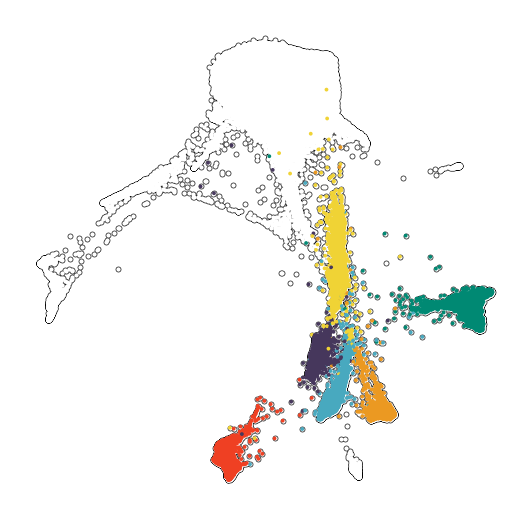

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K5tumorSP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

(-155549.10961905058,
 131731.51064816257,
 -164898.2359223344,
 100884.31424335291)

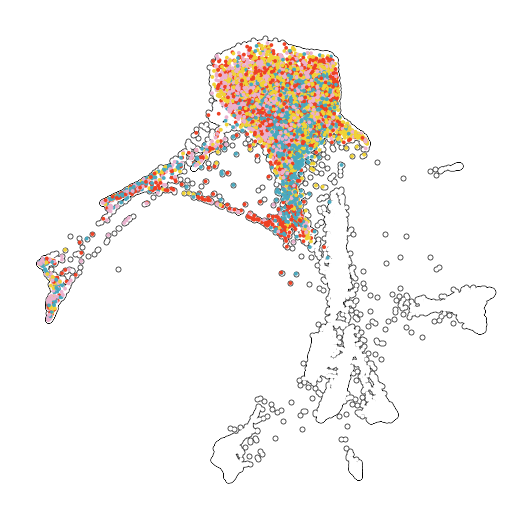

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K5tumorDP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

(-155549.10961905058,
 131731.51064816257,
 -164898.2359223344,
 100884.31424335291)

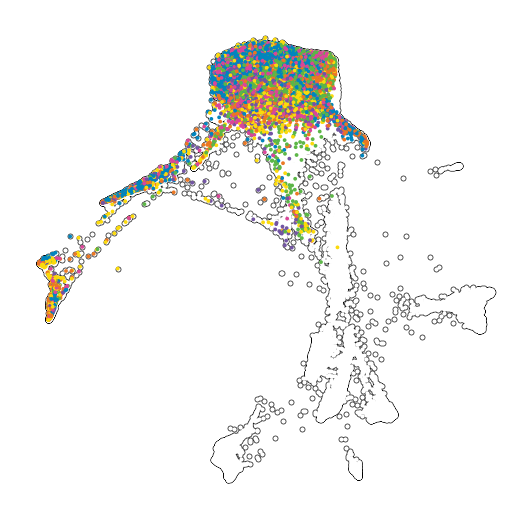

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K4pretumorDP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

(-155549.10961905058,
 131731.51064816257,
 -164898.2359223344,
 100884.31424335291)

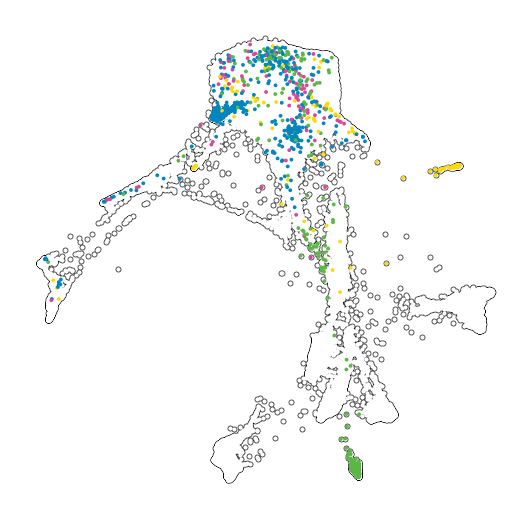

In [ ]:
point_size = 0.5
x = adata.obsm['X_draw_graph_fa'][:,0]
y = adata.obsm['X_draw_graph_fa'][:,1]

f = plt.figure()

subcells = [True] * adata.n_obs
point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*5, color='black')
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size*2, color='white')

subcells = ismember(adata.obs['condition_simple'], ['K4pretumorSP'])[1]

unique_samples = np.unique(adata.obs['sample_id_simple'])
colors = np.array([sample_colors[x] for x in adata.obs['sample_id_simple']])

point_order = np.random.permutation(np.sum(subcells))
my_scatter = plt.scatter(x[subcells][point_order], y[subcells][point_order], s=point_size, color=colors[subcells][point_order])

plt.grid(False)
plt.axis(False)

#### Compute and plot transcriptional signatures from Burdziak, Alonso-Curbelo et al.

In [ ]:
selected_reference = adata.obs['condition'] == 'K4pretumorDP'
adata = zscore_with_subset(adata, selected_reference)
adata.layers['zscore'] = adata.layers['zscore_subcells'].copy()

../utils/anndata_utils.py:38: RuntimeWarning: divide by zero encountered in divide
  zscore = np.divide(np.subtract(mat, mean_val), std_val)
../utils/anndata_utils.py:38: RuntimeWarning: invalid value encountered in divide
  zscore = np.divide(np.subtract(mat, mean_val), std_val)


In [ ]:
selected_signatures = [
    'ADM_specific_0', 'gastric_specific_0', 'mitotic_specific_0', 'neuroendocrine_specific_0', 
    'progenitor_specific_0', 'tuft_specific_30'
]
attach_selected_signatures(adata, '../signatures/', selected_signatures)

100%|██████████| 6/6 [00:00<00:00, 17.31it/s]


Plot merged cell stage signatures in pre-tumor stage, p53 proficient and deficient cells. Colors result from the contribution of multiple signatures on a cell-by-cell basis

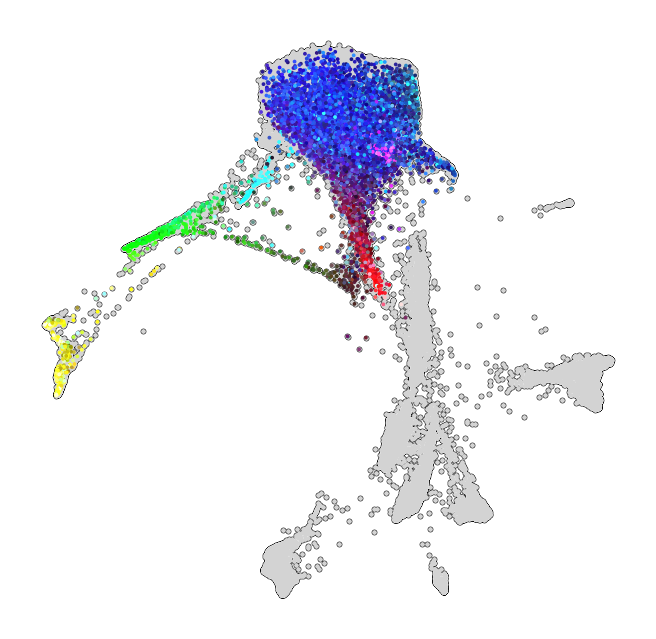

In [ ]:
point_size = 0.5

selected_colors = np.array([[0,1,0], [1,0,0], [0,0,1], [1,1,0], [0,1,1], [1,0.05,1]])
selected_signatures = ['ADM_specific_0', 'progenitor_specific_0', 'gastric_specific_0', 'neuroendocrine_specific_0', 'tuft_specific_30', 'mitotic_specific_0']
Pseudo_colors = get_pseudo_colors(adata, selected_signatures, selected_colors, quantile_threshold=[0, 0.99])

fig,ax=plt.subplots(1,1,figsize=(5,5))
point_order = np.array(random.sample(list(range(adata.n_obs)), k=adata.n_obs))
ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order], adata.obsm['X_draw_graph_fa'][:,1][point_order], s=point_size*5, color='black', rasterized=True)
ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order], adata.obsm['X_draw_graph_fa'][:,1][point_order], s=point_size*2, color='white', rasterized=True)

ax.scatter(adata.obsm['X_draw_graph_fa'][:,0][point_order],
           adata.obsm['X_draw_graph_fa'][:,1][point_order], 
           color='lightgray',s=point_size, rasterized=True)

subcells = np.array(ismember(adata.obs['condition'], ['K5tumorDP'])[1])
adata.obs['premalignant_like'] = pd.Categorical(subcells)
ax.scatter(adata.obsm['X_draw_graph_fa'][subcells,0],
           adata.obsm['X_draw_graph_fa'][subcells,1],
           c=Pseudo_colors[subcells,:],s=point_size, rasterized=True)
ax.set_axis_off()
plt.grid(False)

### Label clusters by signature

First, identify clusters of cells that correspond to cancer-like or premalignant-like signatures. These are defined as clusters that are enriched for tumor or microtumor samples. These classifications will also aid the identification of cells derived from cancer samples that cluster alongside premalignant cells. Most of these were removed during cleaning, but a few remain here.

In [ ]:
adata.obs['pheno_10'] = pd.Categorical(adata.obs['pheno_10'])
adata.obs['pheno_30'] = pd.Categorical(adata.obs['pheno_30'])

/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


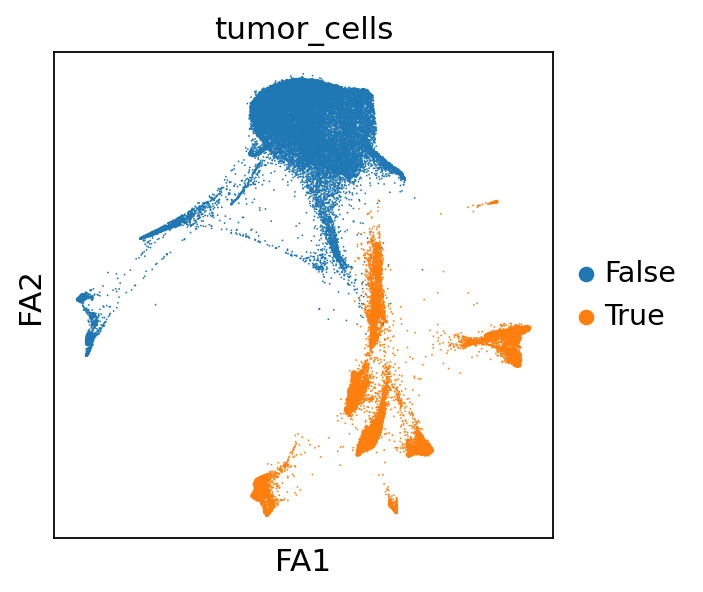

/data/lowe/reyesj3/miniconda3/envs/rpy2_milo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


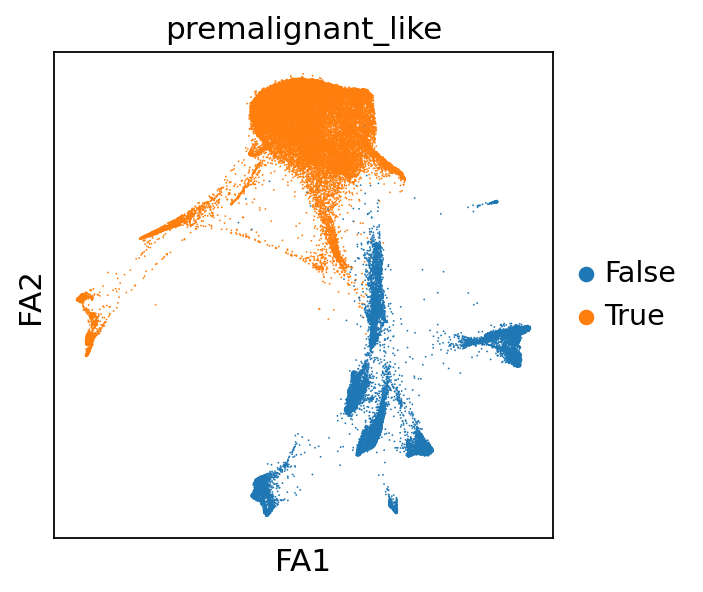

In [ ]:
adata.obs['tumor_cluster'] = pd.Categorical(ismember(adata.obs['pheno_30'], [6,19,32,3,5,7,28,16,13,15,18,21,8,30])[1])
adata.obs['tumor_cells'] = pd.Categorical(np.logical_and(ismember(adata.obs['condition'], ['K4microtumorSP', 'K5tumorSP', 'K5ctrl', 'K6ctrl'])[1], adata.obs['tumor_cluster'] == True))
adata.obs['tumor_samples'] = pd.Categorical(ismember(adata.obs['condition'], ['K4microtumorSP', 'K5tumorSP', 'K5ctrl', 'K6ctrl'])[1])

sc.pl.draw_graph(adata, color='tumor_cells', layout='fa')

subcells = np.array(ismember(adata.obs['condition'], ['K4pretumorDP', 'K4pretumorSP', 'K5tumorDP'])[1])
adata.obs['premalignant_like'] = pd.Categorical(subcells)
sc.pl.draw_graph(adata, color='premalignant_like', layout='fa')

Now, I assign cell state identity on the basis of signatures from Burdziak, Alonso-Curbelo et al. and phenograph clusters with k=30. I only annotate pretumor cells based on these signatures

In [ ]:
adata_sub = adata[ismember(adata.obs['condition'],['K4pretumorDP', 'K4pretumorSP', 'K5tumorDP'])[1],:].copy()

Annotate clusters with phenograph k=30

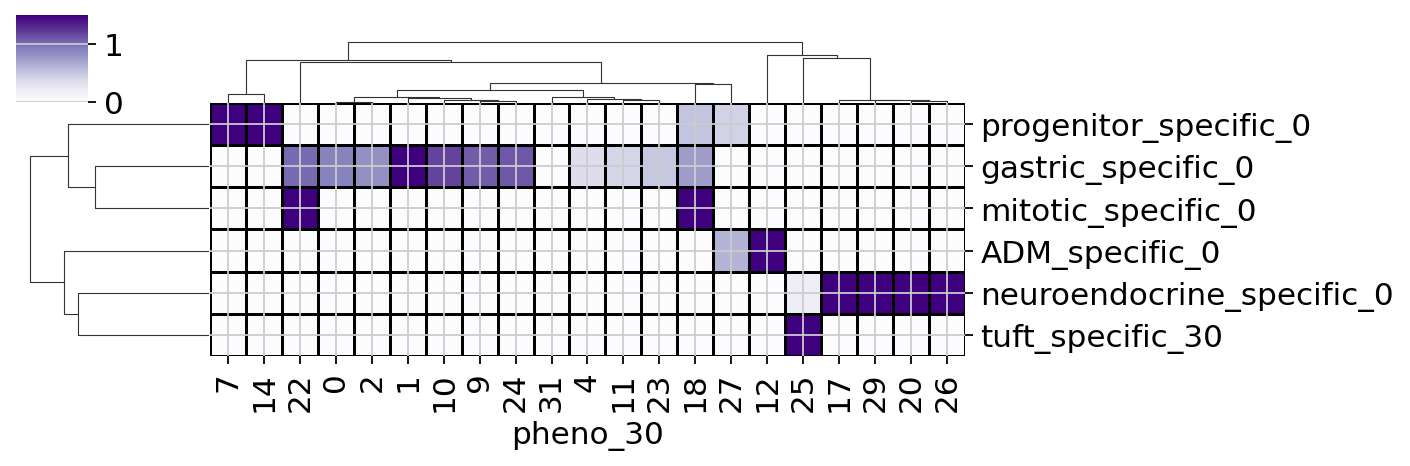

In [ ]:
df = adata_sub.obs[selected_signatures + ['pheno_30']].groupby('pheno_30').agg('mean')
df = df - df.mean(axis=0)
df = df / np.std(df, axis=0)
sns.clustermap(df.T, figsize=[9,3], method='ward', dendrogram_ratio=0.2, cmap='Purples', linewidths = 0.5, vmin=0, vmax=1.5, linecolor='black')

In [ ]:
cell_type = np.array(["6. Gastric-like"] * adata.n_obs, dtype=object)
cell_type[ismember(adata.obs['pheno_30'], [12])[1]] = '3. ADM'
cell_type[ismember(adata.obs['pheno_30'], [7,14,27])[1]] = '8. Progenitor-like'
cell_type[ismember(adata.obs['pheno_30'], [22,0,2,1,10,9,24,31,4,11,23,18])[1]] = '6. Gastric-like'
cell_type[ismember(adata.obs['pheno_30'], [17,29,20,26])[1]] = '1. Neuroendocrine' 
cell_type[ismember(adata.obs['pheno_30'], [25])[1]] = '2. Tuft' ## I assigned cluster 42 to neuroendocrine because it belongs to cluster 26 in coarser clustering
cell_type[ismember(adata.obs['pheno_30'], [22,18])[1]] = '7. Mitotic'
cell_type[ismember(adata.obs['tumor_cells'], [True])[1]] = '9. Tumor'
cell_type[np.logical_and(adata.obs['tumor_samples'] == True, adata.obs['tumor_cells'] == False)] = '9. Tumor_premalignant_like'

adata.obs['cell_type'] = cell_type

Import refined annotations from main figure layouts for consistency. The added value in this notebook is the annotation of Tumor p53 proficient samples

In [ ]:
main_layout_obs = "../data/Reyes_KPLOH_SUBSET_pretumor_PDAC__annotated.csv"
df = pd.read_csv(main_layout_obs, index_col = 0)
df

,cell_type,cell_type_simple,tumor_cells,premalignant_like,tumor_samples,karyotype_simple,condition_simple
254_RH_PanINPM_Kate_CD45_1_4_GGCTCGACATCACGAT,9. Tumor,Cancer,True,False,True,LOHrearranged,K4pretumorSP
254_RH_PanINPM_Kate_CD45_1_4_TTTCCTCCAGCCAGAA,9. Tumor,Cancer,True,False,True,LOHrearranged,K4pretumorSP
254_RH_PanINPM_Kate_CD45_1_4_CCTATTAGTCTCCACT,9. Tumor,Cancer,True,False,True,LOHrearranged,K4pretumorSP
254_RH_PanINPM_Kate_CD45_1_4_TTCTTAGTCTGAAAGA,9. Tumor,Cancer,True,False,True,LOHrearranged,K4pretumorSP
254_RH_PanINPM_Kate_CD45_1_4_GCTTCCATCGGTGTCG,9. Tumor,Cancer,True,False,True,LOHrearranged,K4pretumorSP
...,...,...,...,...,...,...,...
Ag-PDAC-PT-Kate_GTAACTGAGCGCTTAT,9. Tumor,Cancer,True,False,True,CancerGenome,K5tumorSP
Ag-PDAC-PT-Kate_ACAGCTAGTCGTTGTA,9. Tumor,Cancer,True,False,True,CancerGenome,K5tumorSP
Ag-Lung-Mets-Kate_TCGAGGCTCCGCGCAA,9. Tumor,Cancer,True,False,True,CancerGenome,K5tumorSP
Ag-PDAC-PT-Kate_AGGGAGTTCGGAAATA,9. Tumor,Cancer,True,False,True,CancerGenome,K5tumorSP


In [ ]:
adata.obs_names = [re.sub("-\d+-\d+$", "", x) for x in adata.obs_names]

In [ ]:
cell_type = adata.obs['cell_type'].to_numpy()
predefined_cell_type = df['cell_type'].to_numpy()
cell_type[ismember(df.index.to_numpy(), adata.obs_names)[0]] = predefined_cell_type.copy()
adata.obs['cell_type'] = cell_type.copy()

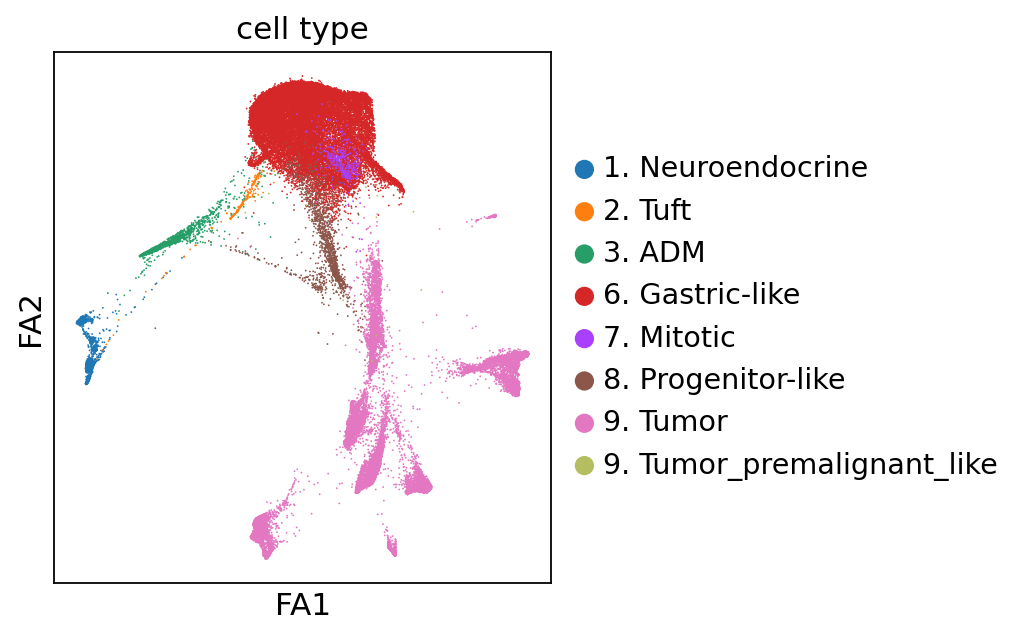

In [ ]:
sc.pl.scatter(adata, basis = 'draw_graph_fa', color='cell_type')

#### Compute distribution of cell states of SP and DP cells per sample or per mouse

In [ ]:
adata.obs['sample_id'] = [re.sub('K\d.*?_', '', x) for x in adata.obs['replicate_id']]
adata.obs['sample_id'] = [re.sub('_[^_]*$', '', x) for x in adata.obs['sample_id']]

In [ ]:
colors = ['gold', 'lightskyblue', 'limegreen', 'navy', 'mediumorchid', 'red']

Text(0.5, 1.0, 'Pre-tumor p53 deficient')

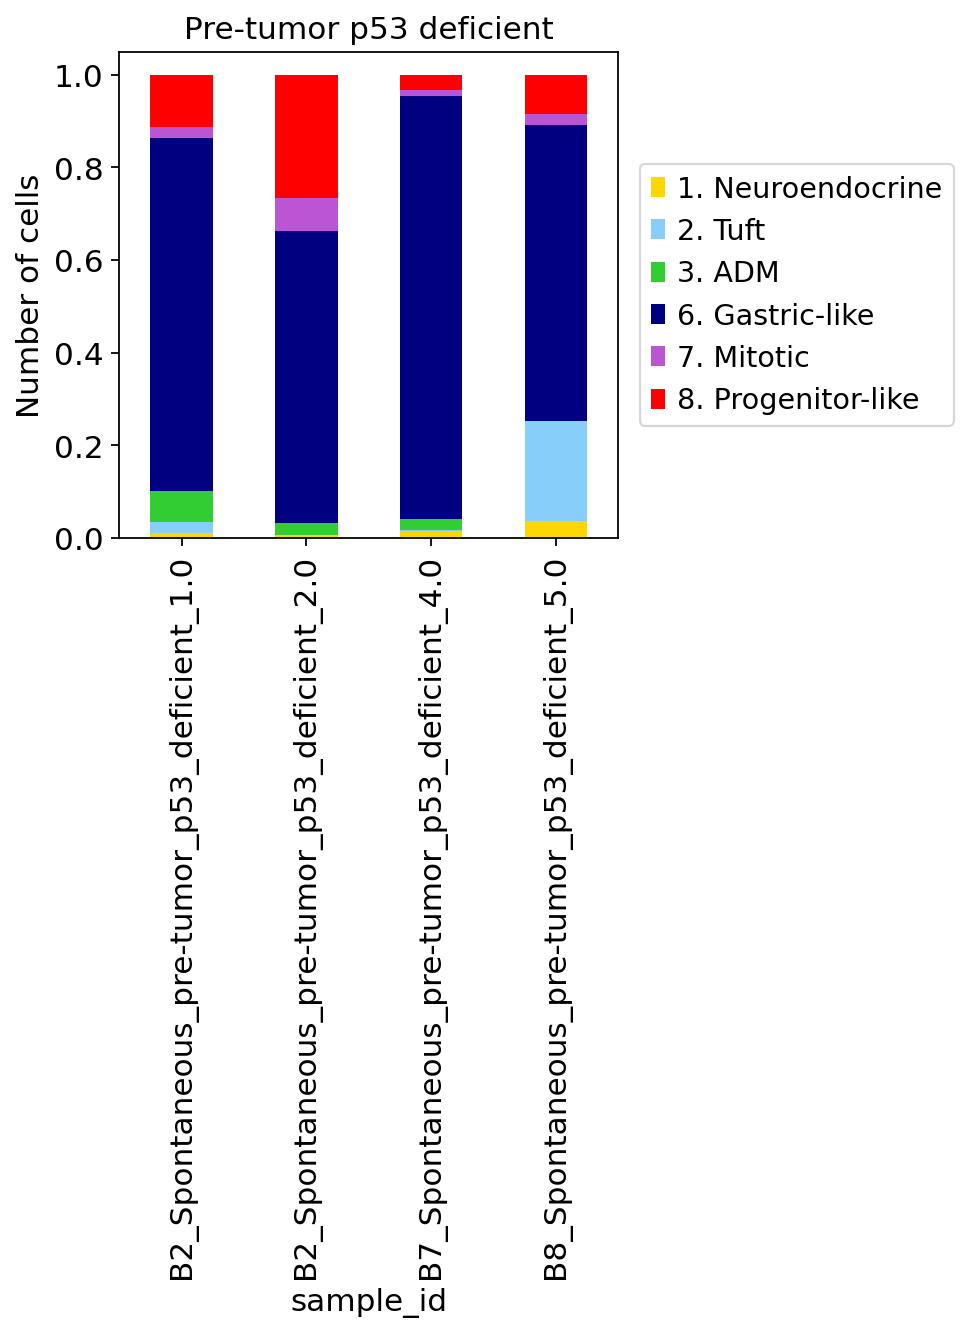

In [ ]:
subcells = ismember(adata.obs['condition'], ['K4pretumorSP'])[1]
df = adata[subcells,:].obs[['cell_type', 'sample_id', 'unclear']].groupby(['sample_id', 'cell_type'], sort=True).size().unstack()
df = df.T / df.sum(axis=1)
df.T.plot(kind='bar', stacked=True, color = colors).legend(loc='right', bbox_to_anchor=[1,0,0.7,1])
plt.grid(False)
plt.ylabel('Number of cells')
plt.title('Pre-tumor p53 deficient')

Text(0.5, 1.0, 'Pre-tumor p53 proficient')

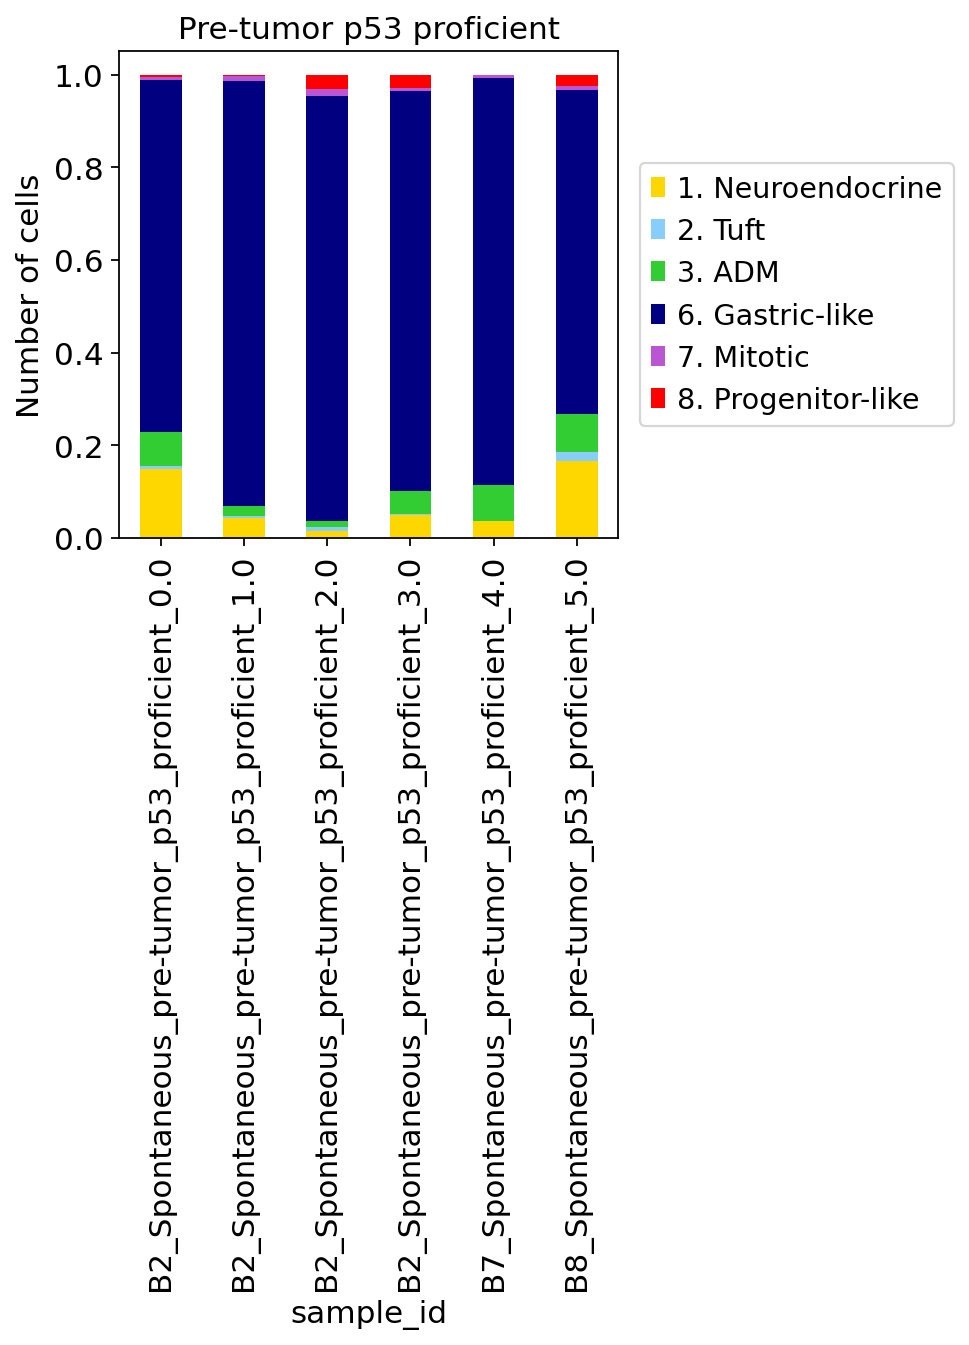

In [ ]:
subcells = ismember(adata.obs['condition'], ['K4pretumorDP'])[1]
df = adata[subcells,:].obs[['cell_type', 'sample_id', 'unclear']].groupby(['sample_id', 'cell_type'], sort=True).size().unstack()
df = df.T / df.sum(axis=1)
df.T.plot(kind='bar', stacked=True, color = colors).legend(loc='right', bbox_to_anchor=[1,0,0.7,1])
plt.grid(False)
plt.ylabel('Number of cells')
plt.title('Pre-tumor p53 proficient')

Tumor p53 proficient 0 is renamed as sample 12 in main figure

Text(0.5, 1.0, 'Tumor p53 proficient')

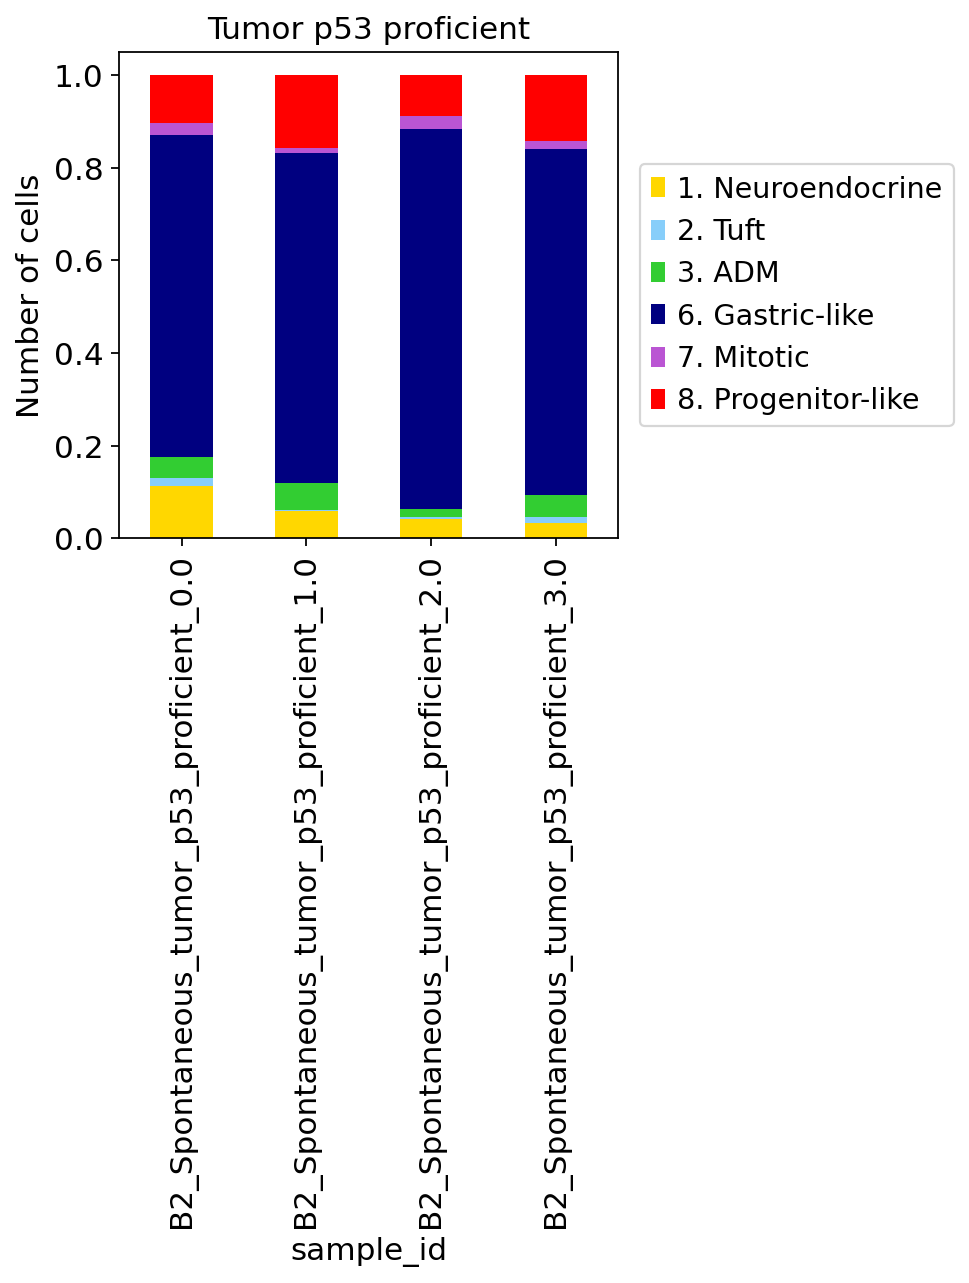

In [ ]:
subcells = ismember(adata.obs['condition'], ['K5tumorDP'])[1]
df = adata[subcells,:].obs[['cell_type', 'sample_id', 'unclear']].groupby(['sample_id', 'cell_type'], sort=True).size().unstack()
df = df.T / df.sum(axis=1)
df.T.plot(kind='bar', stacked=True, color = colors).legend(loc='right', bbox_to_anchor=[1,0,0.7,1])
plt.grid(False)
plt.ylabel('Number of cells')
plt.title('Tumor p53 proficient')